# Notebook companion — Umbral crítico de microrefugios (ADR-0015)

> **Complementa** `notebook_analisis.ipynb` (Esmeralda). Aquel muestra el *baseline*:
> en Marte la población colapsa o queda **dormida** sin ayuda. Éste responde la
> **pregunta de investigación** del proyecto:
>
> *¿Con qué **frecuencia** y **magnitud** mínimas deben aparecer microrefugios húmedos
> transitorios (salmueras delicuescentes) para que una población **persista** en un
> subsuelo planetario, en vez de extinguirse?* (ADR-0015)

Barremos **frecuencia × magnitud** del evento `SalmueraDelicuescente` sobre ensambles
Montecarlo (semillas explícitas) y ubicamos el **umbral crítico**: debajo la población
se extingue, encima persiste. Todo el cómputo vive en `astrobiosim.analysis.barrido`
(reusa el orquestador; el notebook solo lo llama y grafica).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from astrobiosim.analysis.barrido import (
    FabricaModoAnalogico,
    ResultadoBarrido,
    barrido_microrefugios,
)
from astrobiosim.core.microorganism import DRadiodurans, EColi
from astrobiosim.data.loaders import cargar_atacama
from astrobiosim.data.resampling import Entorno

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Configuración

In [2]:
def _localizar_data_dir() -> Path:
    for candidato in (Path("data/processed"), Path("../data/processed")):
        if candidato.exists():
            return candidato
    raise FileNotFoundError("No encuentro data/processed (corré desde la raíz o desde notebooks/).")


DATA = _localizar_data_dir()
df_marte = cargar_atacama(str(DATA / "datos_atacama_2025_EXTREMOS_REALES.csv"))

SHAPE = (32, 32)       # grilla espacial
N_PUNTOS = 12          # lado de la malla del barrido (12x12 = 144 puntos)
N_CORRIDAS = 8         # réplicas Montecarlo por punto
N_ITER = 200           # ticks por corrida (None = año completo, 365; menos = más rápido)
SEMILLA_BASE = 0
N_PROCESOS = 8

print(f"Marte (Atacama): {len(df_marte)} días | a_w medio {df_marte.a_w.mean():.3f} "
      f"(máx {df_marte.a_w.max():.3f}) — nunca llega a 0.90 para crecer sin refugios")

Marte (Atacama): 365 días | a_w medio 0.187 (máx 0.518) — nunca llega a 0.90 para crecer sin refugios


### Función de graficado

Dos mapas de calor por barrido: **probabilidad de persistencia** y **fracción viva media**
al final. La línea blanca punteada es el **umbral crítico** (contorno de probabilidad 0.5):
debajo/izquierda la población se extingue, arriba/derecha persiste.

In [3]:
def graficar_barrido(res: ResultadoBarrido, titulo: str, etiqueta_mag: str) -> None:
    frec, magn = res.frecuencias, res.magnitudes
    extent = [frec[0], frec[-1], magn[0], magn[-1]]
    malla_f, malla_m = np.meshgrid(frec, magn)
    curva = res.curva_critica(0.5)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8))
    for ax, datos, sub, cmap in (
        (ax1, res.prob_persistencia, f"Prob. de persistencia ({res.poblacion})", "viridis"),
        (ax2, res.fraccion_media, f"Fracción media final ({res.poblacion})", "magma"),
    ):
        im = ax.imshow(datos, origin="lower", extent=extent, aspect="auto", cmap=cmap, vmin=0, vmax=1)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.contour(malla_f, malla_m, res.prob_persistencia, levels=[0.5],
                   colors="white", linewidths=1.6, linestyles="--")
        ok = ~np.isnan(curva)
        ax.plot(frec[ok], curva[ok], "o-", color="white", ms=3, lw=1.0, alpha=0.9)
        ax.set_title(sub)
        ax.set_xlabel("Frecuencia · probabilidad_disparo (por tick)")
        ax.set_ylabel(etiqueta_mag)
    fig.suptitle(titulo, fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

## 1. *E. coli* — necesita microrefugios (umbral extinción → persistencia)

*E. coli* es mesófila: su umbral de supervivencia es `a_w_sup_min = 0.5`, así que en Marte
(a_w medio ~0.19) **muere** sin agua. Barremos **frecuencia × radio** del refugio, con
refugios húmedos (a_w pico 0.98) y duraderos (10–20 ticks). La persistencia se mide sobre
la población **viva** (activa + latente): que quede al menos una célula viva al final.

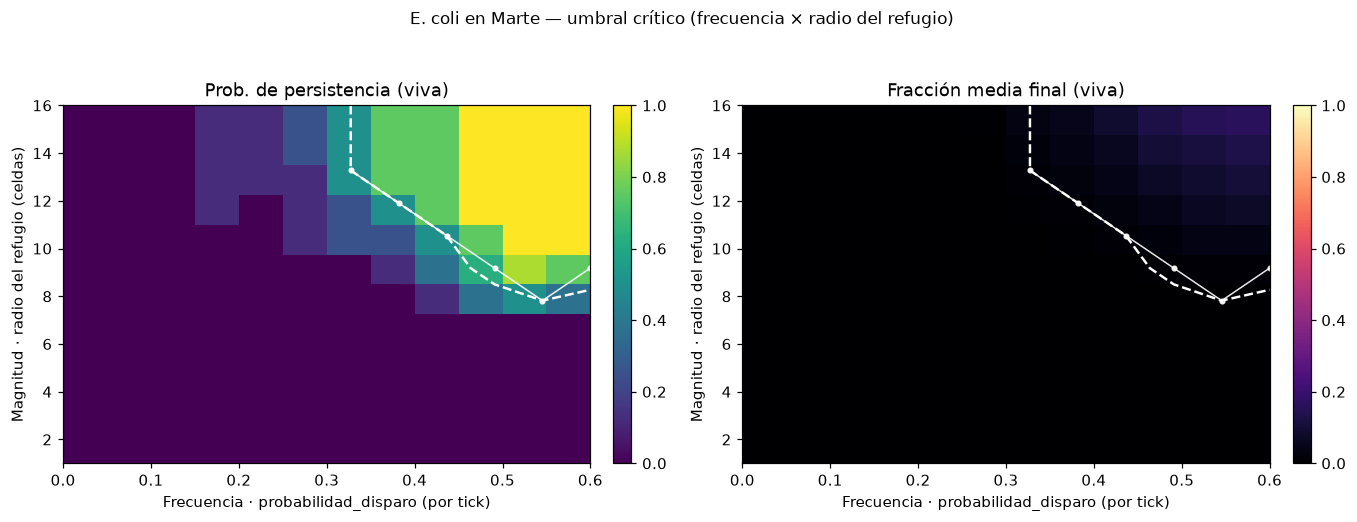

In [4]:
res_ecoli = barrido_microrefugios(
    FabricaModoAnalogico(df_marte, Entorno.MARTE, SHAPE),
    EColi(),
    frecuencias=np.linspace(0.0, 0.6, N_PUNTOS),
    magnitudes=np.linspace(1.0, 16.0, N_PUNTOS),
    eje_magnitud="radio",
    salmuera_base={
        "a_w_objetivo_min": 0.98, "a_w_objetivo_max": 0.98,
        "duracion_min_ticks": 10.0, "duracion_max_ticks": 20.0,
    },
    poblacion="viva",
    shape=SHAPE, n_corridas=N_CORRIDAS, n_iteraciones=N_ITER,
    semilla_base=SEMILLA_BASE, n_procesos=N_PROCESOS,
)
graficar_barrido(
    res_ecoli,
    "E. coli en Marte — umbral crítico (frecuencia × radio del refugio)",
    "Magnitud · radio del refugio (celdas)",
)

In [5]:
# Umbral crítico: radio mínimo con prob. de persistencia >= 0.5, por frecuencia.
for f, r in zip(res_ecoli.frecuencias, res_ecoli.curva_critica(0.5), strict=True):
    print(f"frecuencia {f:.2f}  →  " + ("nunca persiste en el rango" if np.isnan(r) else f"radio >= {r:.1f} celdas"))

frecuencia 0.00  →  nunca persiste en el rango
frecuencia 0.05  →  nunca persiste en el rango
frecuencia 0.11  →  nunca persiste en el rango
frecuencia 0.16  →  nunca persiste en el rango
frecuencia 0.22  →  nunca persiste en el rango
frecuencia 0.27  →  nunca persiste en el rango
frecuencia 0.33  →  radio >= 13.3 celdas
frecuencia 0.38  →  radio >= 11.9 celdas
frecuencia 0.44  →  radio >= 10.5 celdas
frecuencia 0.49  →  radio >= 9.2 celdas
frecuencia 0.55  →  radio >= 7.8 celdas
frecuencia 0.60  →  radio >= 9.2 celdas


**Lectura.** Por debajo de una frecuencia mínima la población se extingue *haga lo que haga*
el radio. Por encima, persiste solo si el radio supera un umbral que **baja al aumentar la
frecuencia** (más refugios ⇒ pueden ser más chicos). Ésa es la respuesta cuantitativa a la
pregunta de investigación para *E. coli*: los microrefugios deben ser **suficientemente
grandes Y frecuentes** para tender un puente sobre los intervalos secos letales.

## 2. *D. radiodurans* — sobrevive dormida (sin umbral de extinción)

*D. radiodurans* es anhidrobiótica: `a_w_sup_min = 0`. **Nunca muere por sequedad**; cuando
el agua falta, entra en **latencia** (viva, dormida) y espera. Barremos frecuencia × a_w
pico del refugio con la misma métrica *viva*. El resultado esperado es un mapa **casi
uniforme**: persiste en todo el rango, con o sin refugios.

prob. de persistencia (viva) — min: 1.0 | max: 1.0


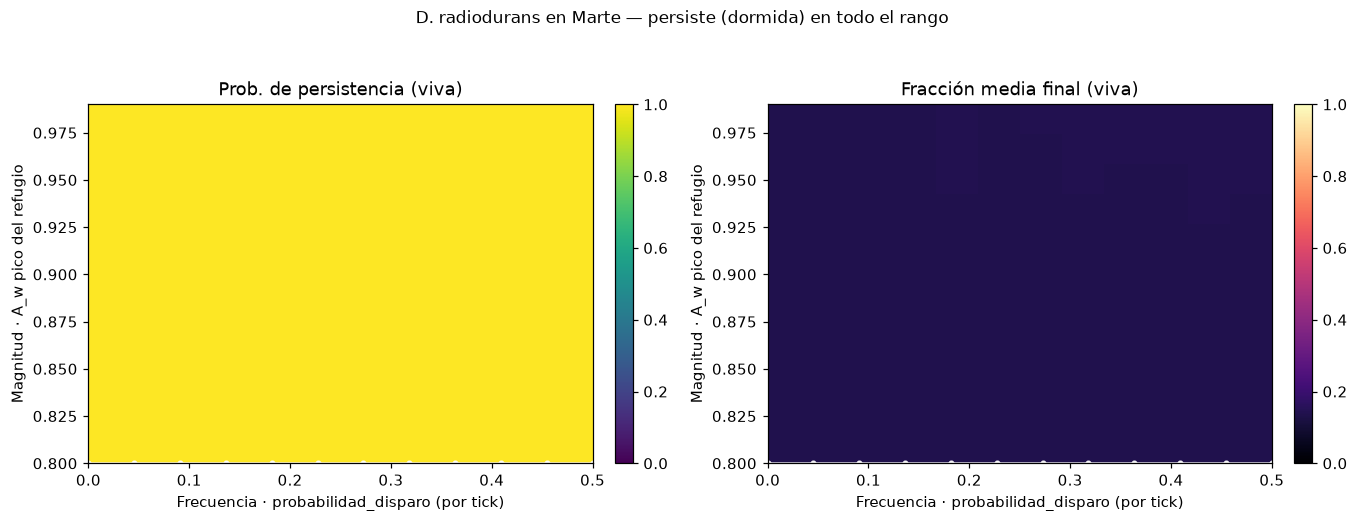

In [6]:
res_drad = barrido_microrefugios(
    FabricaModoAnalogico(df_marte, Entorno.MARTE, SHAPE),
    DRadiodurans(),
    frecuencias=np.linspace(0.0, 0.5, N_PUNTOS),
    magnitudes=np.linspace(0.80, 0.99, N_PUNTOS),
    eje_magnitud="a_w",
    poblacion="viva",
    shape=SHAPE, n_corridas=N_CORRIDAS, n_iteraciones=N_ITER,
    semilla_base=SEMILLA_BASE, n_procesos=N_PROCESOS,
)
print("prob. de persistencia (viva) — min:", round(float(res_drad.prob_persistencia.min()), 2),
      "| max:", round(float(res_drad.prob_persistencia.max()), 2))
graficar_barrido(
    res_drad,
    "D. radiodurans en Marte — persiste (dormida) en todo el rango",
    "Magnitud · A_w pico del refugio",
)

**Lectura.** Para la extremófila los microrefugios **no son necesarios para sobrevivir**:
persiste dormida en todo el espacio de parámetros. (Su umbral interesante no es la extinción
sino la **reactivación**: si medimos la población *activa* —creciendo— en lugar de la *viva*,
aparece una señal fina justo en `a_w ≈ 0.90`, su umbral de crecimiento. Ver el parámetro
`poblacion="activa"` del módulo.)

### El contraste es la respuesta
- **Mesófila (*E. coli*)**: sin microrefugios grandes y frecuentes → **se extingue**.
- **Extremófila (*D. radiodurans*)**: sobrevive **dormida** sin ayuda; los microrefugios
  solo modulan cuánto llega a **reactivarse**.

## Reproducibilidad y mapa exhaustivo

Los mapas se regeneran idénticos con la misma `semilla_base` (cada punto es determinista).

In [7]:
# Verificación de reproducibilidad (malla chica).
kw = dict(eje_magnitud="radio", shape=(20, 20), n_corridas=4, n_iteraciones=60,
          n_procesos=4, semilla_base=0)
_a = barrido_microrefugios(FabricaModoAnalogico(df_marte, Entorno.MARTE, (20, 20)), EColi(),
                           frecuencias=np.linspace(0, 0.5, 3), magnitudes=np.linspace(1, 12, 3), **kw)
_b = barrido_microrefugios(FabricaModoAnalogico(df_marte, Entorno.MARTE, (20, 20)), EColi(),
                           frecuencias=np.linspace(0, 0.5, 3), magnitudes=np.linspace(1, 12, 3), **kw)
np.testing.assert_array_equal(_a.prob_persistencia, _b.prob_persistencia)
print("Reproducibilidad verificada: misma semilla_base → mismo mapa.")

Reproducibilidad verificada: misma semilla_base → mismo mapa.


Para el **mapa exhaustivo** (16×16 × 30 réplicas, año completo) conviene el script, que
paraleliza y guarda PNG + CSV:

```bash
python scripts/barrido_microrefugios.py --especie ecoli --magnitud radio \
    --refugio-a-w 0.98 --refugio-duracion 15 --puntos 16 --corridas 30
```

El eje de magnitud (`--magnitud a_w|duracion|radio`) y la métrica de persistencia
(`--poblacion viva|activa`) son ajustables.